## 0105-ADV-ML-II-Dimensionality-reduction-weekly-project

### 1. Introduction

The second-hand car market is vast, and predicting the price of a used car is a challenging task due to various factors influencing the price. Feature engineering and dimensionality reduction play a crucial role in improving the performance of predictive models by enhancing the quality of input data and reducing noise.

### 2. Dataset Overview

We will use a second-hand car sales dataset containing features such as make, model, year, mileage, state, price, etc. The dataset can be obtained from public repositories like Kaggle or scraped from online car listing websites.

### 3. Data Preprocessing

### 3.1 Load Data

In [131]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

import warnings
warnings.filterwarnings("ignore")

In [132]:
df2= pd.read_csv("/content/second_hand_cars.csv")

In [133]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Company Name              2500 non-null   object
 1   Car Name                  2500 non-null   object
 2   Variant                   2238 non-null   object
 3   Fuel Type                 2500 non-null   object
 4   Tyre Condition            2500 non-null   object
 5   Make Year                 2500 non-null   int64 
 6   Owner Type                2500 non-null   object
 7   Registration Number       2500 non-null   object
 8   Mileage                   2500 non-null   int64 
 9   Price                     2500 non-null   int64 
 10  Transmission Type         2500 non-null   object
 11  Body Color                2500 non-null   object
 12  Service Record            2500 non-null   object
 13  Insurance                 2500 non-null   object
 14  Registration Certificate

In [134]:
df2.head()

,Company Name,Car Name,Variant,Fuel Type,Tyre Condition,Make Year,Owner Type,Registration Number,Mileage,Price,Transmission Type,Body Color,Service Record,Insurance,Registration Certificate,Accessories
0,Maruti Suzuki,Cruze,EX,CNG,Needs Replacement,2018,Second,84-436-5584,52798,759107,Manual,Grey,Major Service at 50418 km,No Current Insurance,Not Available,"Music System, Sunroof, Alloy Wheels"
1,Kia,Seltos,RXE,Petrol,New,2020,Third,79-114-3166,43412,505071,Automatic,Maroon,Major Service at 131313 km,No Current Insurance,Available,NaN
2,Kia,Accord,RXE,Petrol,New,2022,Second,41-358-3344,95219,635322,Automatic (Tiptronic),Black,No Service Record,No Current Insurance,Available,NaN
3,Nissan,Seltos,Highline,Diesel,Used,2024,Third,92-708-1763,70370,483152,Automatic (Tiptronic),Maroon,Major Service at 98115 km,Valid Until [date],Available,"Music System, Alloy Wheels"
4,Chevrolet,Kwid,Highline,Petrol,Used,2018,Second,76-154-5485,85852,712961,Automatic (Tiptronic),Silver,Major Service at 135665 km,No Current Insurance,Not Available,"GPS, Music System"


### Data Cleaning

In [135]:
#identify columns with missing values
df2.columns[df2.isna().any()]

Index(['Variant', 'Accessories'], dtype='object')

In [136]:
(df2.isna().mean() * 100)

,0
Company Name,0.00
Car Name,0.00
Variant,10.48
Fuel Type,0.00
Tyre Condition,0.00
Make Year,0.00
Owner Type,0.00
Registration Number,0.00
Mileage,0.00
Price,0.00


In [137]:
# immpute the missing values
df2['Variant'] = df2['Variant'].fillna(df2['Variant'].mode()[0])

In [138]:
df2['Accessories_missing'] = df2['Accessories'].isna().astype(int)

In [139]:
#check for duplicates

df2.duplicated().sum()

np.int64(0)

In [140]:
#convert category columns with object datatype to 'category' this makes it reduces memory usage and makes categorical intent explicit
cat_cols = [
    'Company Name', 'Car Name', 'Variant', 'Fuel Type', 'Tyre Condition',
    'Owner Type', 'Transmission Type', 'Body Color', 'Service Record',
    'Insurance', 'Registration Certificate', 'Accessories'
]

df2[cat_cols] = df2[cat_cols].astype('category')

In [141]:
if 'Registration Number' in df2.columns:
    df2 = df2.drop(columns=['Registration Number'])

In [142]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Company Name              2500 non-null   category
 1   Car Name                  2500 non-null   category
 2   Variant                   2500 non-null   category
 3   Fuel Type                 2500 non-null   category
 4   Tyre Condition            2500 non-null   category
 5   Make Year                 2500 non-null   int64   
 6   Owner Type                2500 non-null   category
 7   Mileage                   2500 non-null   int64   
 8   Price                     2500 non-null   int64   
 9   Transmission Type         2500 non-null   category
 10  Body Color                2500 non-null   category
 11  Service Record            2500 non-null   category
 12  Insurance                 2500 non-null   category
 13  Registration Certificate  2500 non-null   catego

### EDA

In [172]:
df2.describe()

,Mileage,Price,Accessories_missing,Car_Age
count,2500.000000,2500.000000,2500.000000,2500.000000
mean,104777.792000,608120.897600,0.192800,6.478400
std,55544.487467,231056.126713,0.394576,2.894146
min,10010.000000,200176.000000,0.000000,2.000000
25%,56313.000000,407791.000000,0.000000,4.000000
50%,104209.500000,612012.500000,0.000000,6.000000
75%,152149.250000,804567.000000,0.000000,9.000000
max,199755.000000,999826.000000,1.000000,11.000000


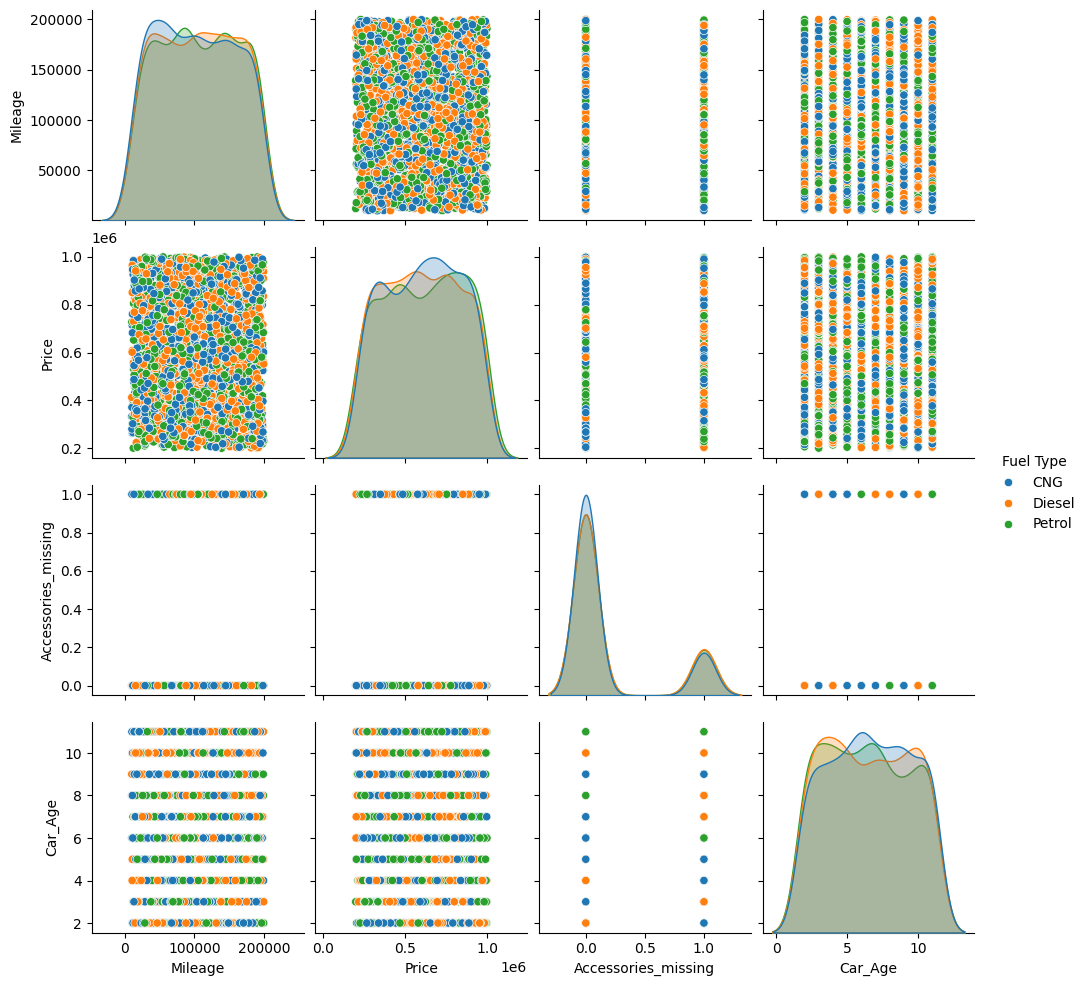

In [176]:
sns.pairplot(data= df2, hue= 'Fuel Type', diag_kind= 'kde')

- No linear relationship identified , variable are overlapping with no clear patterns

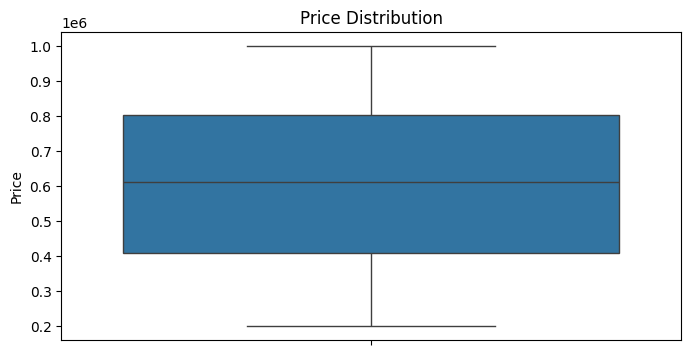

In [143]:
plt.figure(figsize=(8,4))
sns.boxplot(y=df2['Price'])
plt.title("Price Distribution")
plt.show()

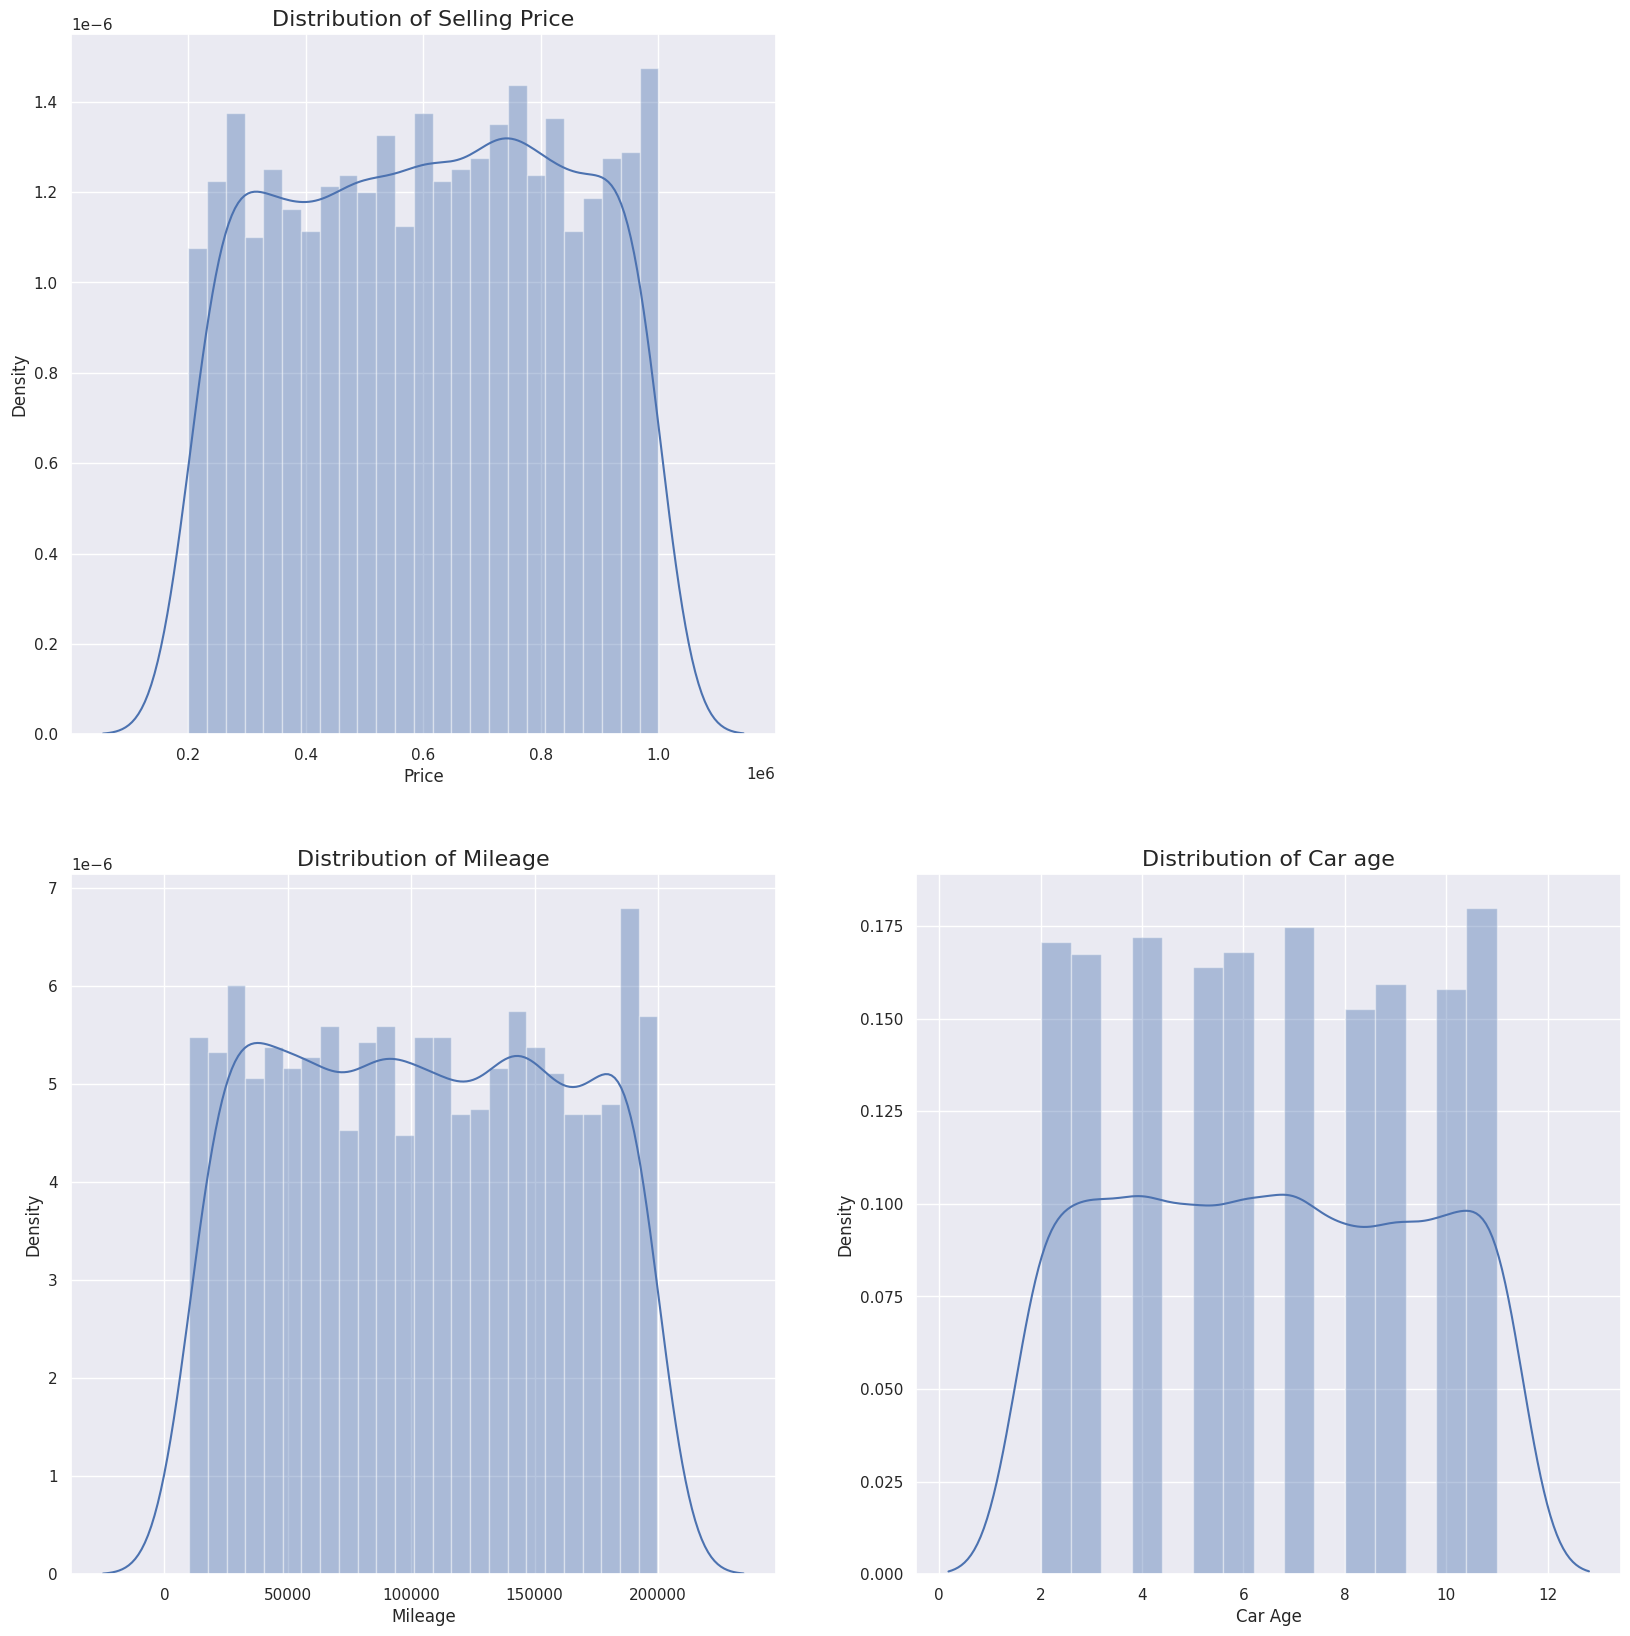

In [179]:
# Let's see the distribution of the two variable from our data
fig = plt.figure(figsize=(20,20)) # create figure

sns.set(font_scale= 1)
sns.set_style('darkgrid')

ax0 = fig.add_subplot(2, 2, 1) # add subplot 1 (2 row, 2 columns, first plot)
ax2 = fig.add_subplot(2, 2, 3) # add subplot 1 (2 row, 2 columns, third plot)
ax3 = fig.add_subplot(2, 2, 4) # add subplot 1 (2 row, 2 columns, fourth plot)

# Subplot 1: Distplot of 'Price' feature
k1 = sns.distplot(a = df2['Price'], bins= 25, ax=ax0)
ax0.set_title('Distribution of Selling Price', fontsize=16)
ax0.set(xlabel= 'Price', ylabel= 'Density')


# Subplot 3: Distplot of 'Kms_Driven' feature
k1 = sns.distplot(a = df2['Mileage'], bins= 25, ax=ax2)
ax2.set_title('Distribution of Mileage', fontsize=16)
ax2.set(xlabel= 'Mileage', ylabel= 'Density')

# Subplot 4: Distplot of 'No_of_Years' feature
k1 = sns.distplot(a = df2['Car_Age'], bins= 15, ax=ax3)
ax3.set_title('Distribution of Car age', fontsize=16)
ax3.set(xlabel= 'Car Age', ylabel= 'Density')

plt.show()
#fig.savefig("Distributionplot.png")

### Feature Engineering

#### Create new features

In [144]:
# create derived column age of car
current_year = 2026
df2['Car_Age'] = current_year - df2['Make Year']

In [145]:
#drop column make year
df2 = df2.drop(columns=['Make Year'])

 #### Encoding Categorical Features

In [146]:
!pip install category_encoders
from category_encoders import TargetEncoder


In [147]:

high_cardinality_cols = ['Car Name', 'Variant', 'Accessories', 'Company Name']

te = TargetEncoder()

df2_te = df2.copy()
df2_te[high_cardinality_cols] = te.fit_transform(df2[high_cardinality_cols], df2['Price'])

In [148]:
small_cat_cols = [
    'Fuel Type', 'Tyre Condition', 'Owner Type',
    'Transmission Type', 'Body Color', 'Service Record',
    'Insurance', 'Registration Certificate'
]


In [149]:
import category_encoders as ce

te = ce.TargetEncoder(
    cols=['Company Name', 'Car Name', 'Variant', 'Accessories']
)

df2_te = df2.copy()
df2_te[['Company Name', 'Car Name', 'Variant', 'Accessories']] = te.fit_transform(
    df2[['Company Name', 'Car Name', 'Variant', 'Accessories']],
    df2['Price']
)

In [150]:
df2_te = pd.get_dummies(df2_te, columns=small_cat_cols, drop_first=True)

In [151]:
df2_te.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Columns: 873 entries, Company Name to Registration Certificate_Not Available
dtypes: bool(865), float64(4), int64(4)
memory usage: 2.2 MB


### Feature Scaling

In [152]:
num_cols = [
    'Mileage',
    'Car_Age'

]

In [153]:
X = df2_te.drop(columns=['Price'])
y = df2_te['Price']




In [154]:
scaler = StandardScaler()
X_scaled=scaler.fit_transform(X)

## Dimensionality Reduction

### Principal Component Analysis (PCA)

In [155]:
pca=PCA(n_components= 10)
#pca=PCA(0.95)
X_pca=pca.fit_transform(X_scaled)
X_pca.shape

(2500, 10)

In [156]:
pca.explained_variance_ratio_*100

array([0.24235883, 0.23382163, 0.23296849, 0.22411549, 0.20983348,
       0.19795731, 0.19579465, 0.19274159, 0.19096833, 0.18872869])

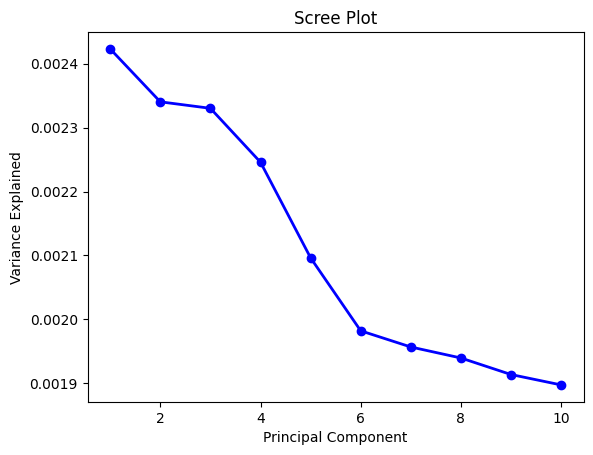

In [157]:
x_pca=pca.fit(X_scaled)
PC_values = np.arange(pca.n_components_) + 1
plt.plot(PC_values,x_pca.explained_variance_ratio_, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.show()

- Variance is distributed against multiple dimensions rather than being captured by small number of components.
- The dataset is non linear therefore we can consider applying non linear dimensionalty reduction methods

In [160]:
import umap
import matplotlib.pyplot as plt

UMAP

In [161]:
mapper= umap.UMAP(
    n_neighbors=30,
    min_dist=0.01,
    metric='cosine'
)
X_umap = mapper.fit_transform(X_scaled)

In [162]:
umap_df = pd.DataFrame(
    data=X_umap,
    columns=['umap_1', 'umap_2']
)
umap_df['Target'] = y

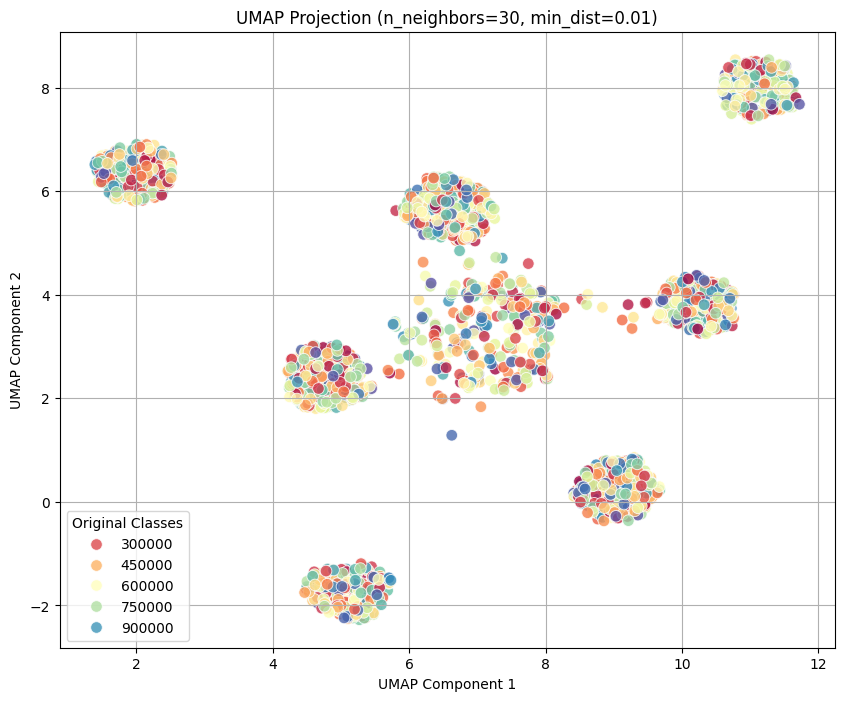

In [163]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='umap_1',
    y='umap_2',
    data=umap_df,
    hue='Target',
    palette='Spectral',
    s=70,
    alpha=0.8
)

plt.title(f"UMAP Projection (n_neighbors={mapper.n_neighbors}, min_dist={mapper.min_dist})")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.legend(title='Original Classes')
plt.grid(True)
plt.show()

- Umap does not help us to naturally cluster price
- descrite groups are very similar


### Modeling and Evaluation

Top Important Features:
Accessories                               0.107154
Mileage                                   0.059304
Car_Age                                   0.056857
Car Name                                  0.055061
Variant                                   0.052761
Company Name                              0.052026
Service Record_No Service Record          0.032508
Registration Certificate_Not Available    0.030669
Fuel Type_Petrol                          0.029044
Tyre Condition_New                        0.027973
dtype: float64


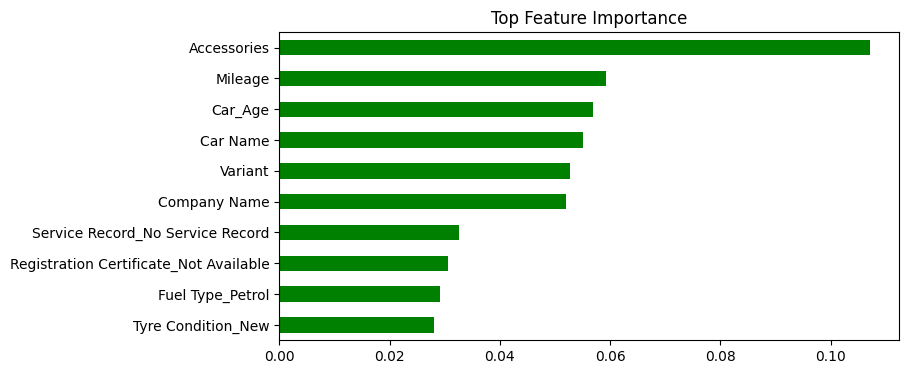

In [164]:
model = ExtraTreesRegressor(n_estimators=200, random_state=42)
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = importances.nlargest(10)

print("Top Important Features:")
print(top_features)

# Plot
plt.figure(figsize=(8,4))
top_features.sort_values().plot(kind='barh', color='green')
plt.title("Top Feature Importance")
plt.show()

- proceed to model training with only important features with only important features

In [165]:
important_features = list(top_features.index)

X_reduced = X[important_features]

# Scaling
scaler = StandardScaler()
X_scaled1 = scaler.fit_transform(X_reduced)

In [166]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled1, y, test_size=0.2, random_state=42
)


In [167]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (2000, 10)
Test shape: (500, 10)


In [168]:
def evaluate_model(model, X_train, y_train, X_test, y_test):

    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    return rmse, mae, r2

In [169]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "SVR": SVR(kernel='rbf')
}

results = []

for name, model in models.items():
    rmse, mae, r2 = evaluate_model(model, X_train, y_train, X_test, y_test)
    results.append([name, rmse, mae, r2])

results_df = pd.DataFrame(results, columns=['Model', 'RMSE', 'MAE', 'R2 Score'])
results_df.set_index("Model", inplace=True)
results_df

,RMSE,MAE,R2 Score
Model,,,
Random Forest,235560.647655,202318.365747,-0.001289
Decision Tree,325090.649838,261604.922000,-0.907054
Ridge,226730.161751,196130.320373,0.072374
Lasso,226729.305823,196127.404871,0.072381
SVR,235959.525849,206155.176845,-0.004683


- Top 10 features only provide less than 10% of the ariance therefore the model could not learn from them adequetely